**Task 1** Import required libraries.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
import numpy as np 
sns.set_theme(style='whitegrid',palette='bright')
plt.rcParams['figure.figsize']=(12,5)

**Task 2** Load Dataset

In [2]:
df=pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Task 3** Dataset Overview

In [3]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [8]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

**Task 4** Data Cleaning

In [9]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df_clean=df.copy()
df_clean['director']=df_clean['director'].fillna("Unknown")
df_clean['country']=df_clean['country'].fillna("unknown")
df_clean['cast']=df_clean['cast'].fillna("unknown")
df_clean['date_added']=df_clean['date_added'].fillna("unknown")
df_clean['rating']=df_clean['rating'].fillna("unknown")
df_clean['duration']=df_clean['duration'].fillna("unknown")

In [12]:
df_clean.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

**Task 5** Outliner Detection 

<Axes: ylabel='release_year'>

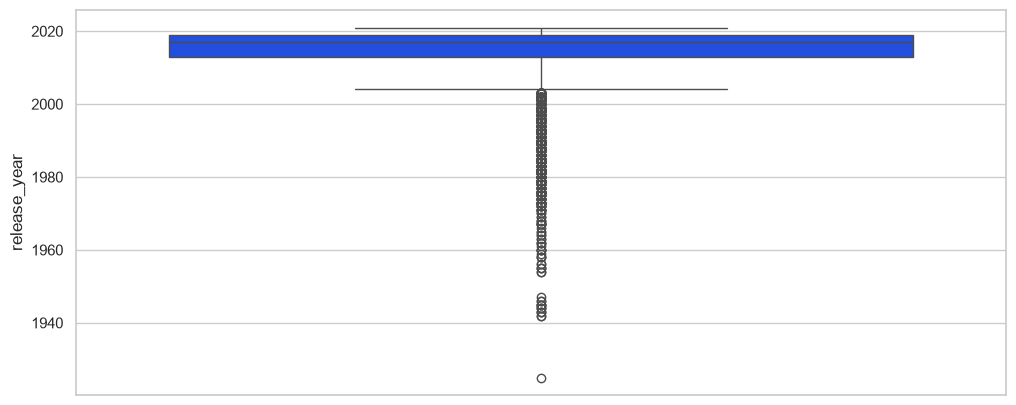

In [13]:
sns.boxplot(data=df_clean,y=df_clean['release_year'])

In [14]:
q1=df_clean['release_year'].quantile(0.25)
q3=df_clean['release_year'].quantile(0.75)
iqr=q3-q1

In [15]:
Lower_Fence=q1-1.5*iqr
Upper_Fence=q3+1.5*iqr
outlier=df_clean[(df_clean['release_year']<Lower_Fence) | (df_clean['release_year']>Upper_Fence)]
outlier

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",unknown,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
26,s27,Movie,Minsara Kanavu,Rajiv Menon,"Arvind Swamy, Kajol, Prabhu Deva, Nassar, S.P....",unknown,"September 21, 2021",1997,TV-PG,147 min,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...
41,s42,Movie,Jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,"September 16, 2021",1975,PG,124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...
...,...,...,...,...,...,...,...,...,...,...,...,...
8764,s8765,Movie,Wyatt Earp,Lawrence Kasdan,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,"January 1, 2020",1994,PG-13,191 min,Action & Adventure,Legendary lawman Wyatt Earp is continually at ...
8766,s8767,Movie,XXx,Rob Cohen,"Vin Diesel, Asia Argento, Marton Csokas, Samue...",United States,"January 1, 2019",2002,PG-13,124 min,"Action & Adventure, Sports Movies",A notorious underground rush-seeker deemed unt...
8768,s8769,Movie,Y Tu Mamá También,Alfonso Cuarón,"Maribel Verdú, Gael García Bernal, Diego Luna,...",Mexico,"June 1, 2017",2001,R,106 min,"Dramas, Independent Movies, International Movies",When rich teens Tenoch and Julio meet the allu...
8770,s8771,Movie,Yaadein,Subhash Ghai,"Jackie Shroff, Hrithik Roshan, Kareena Kapoor,...",India,"March 1, 2018",2001,TV-14,171 min,"Dramas, International Movies, Romantic Movies",Two young lovers set out to overcome the obsta...


**Task 6** Univariate Analysis


<Axes: title={'center': 'RELEASE RATEs'}, xlabel='release_year'>

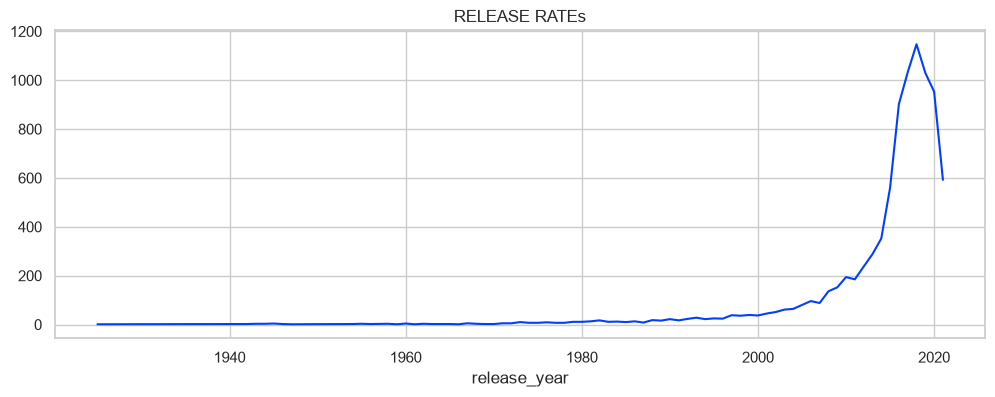

In [16]:
plt.figure(figsize = (12,4))
rate_count = df['release_year'].value_counts()
plt.title("RELEASE RATEs")
sns.lineplot(x =rate_count.index , y= rate_count.values)

<Axes: xlabel='rating', ylabel='count'>

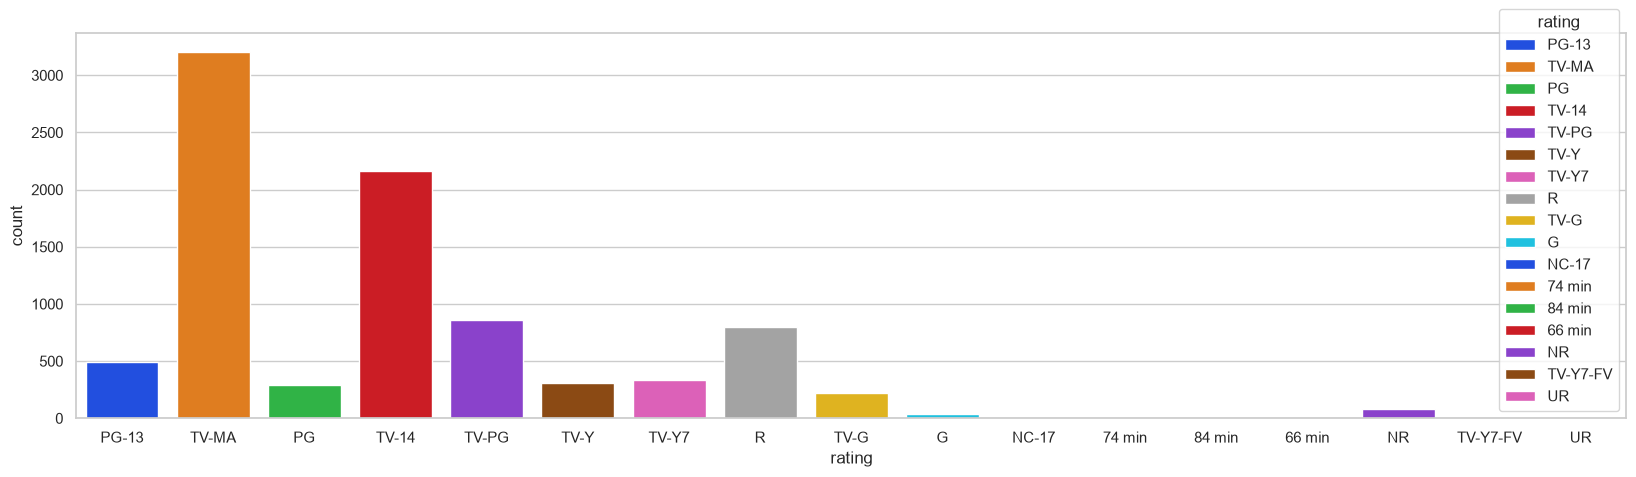

In [17]:
plt.figure(figsize=(20,5))
sns.countplot(x=df.rating,palette='bright',hue=df.rating)


In [18]:
print(int(df['release_year'].mean()))
print(df['release_year'].max())
print(df['release_year'].min())

2014
2021
1925


**Task 7** Bivariate Analysis 

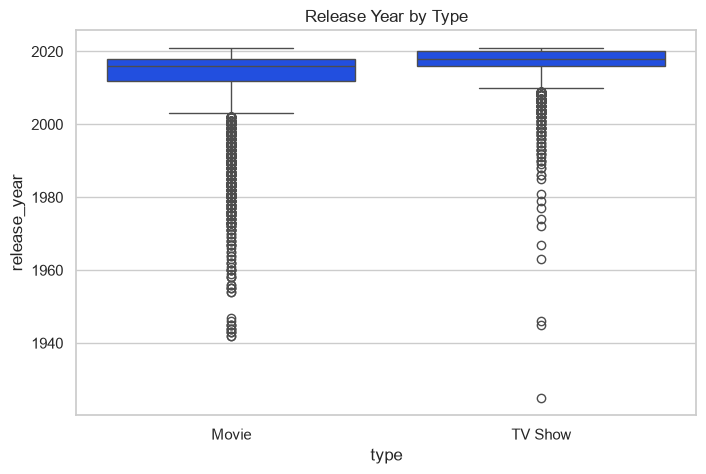

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="type", y="release_year")
plt.title("Release Year by Type")
plt.show()

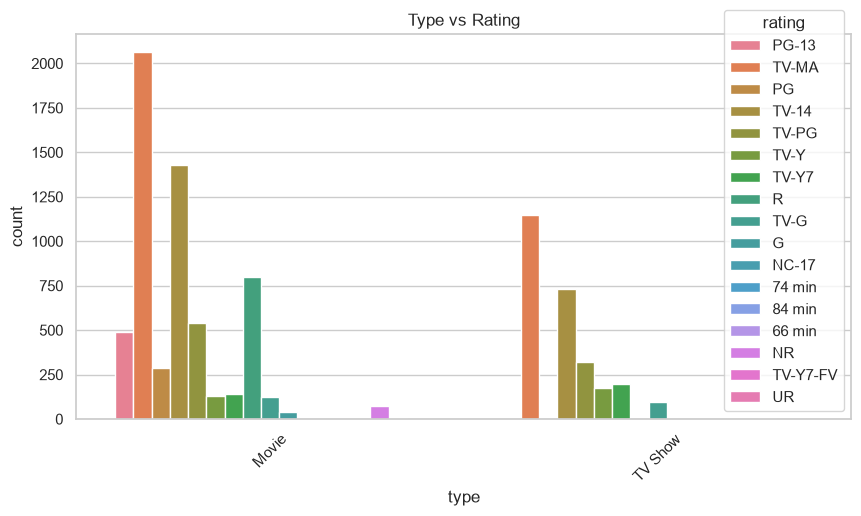

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="type", hue="rating")
plt.title("Type vs Rating")
plt.xticks(rotation=45)
plt.show()


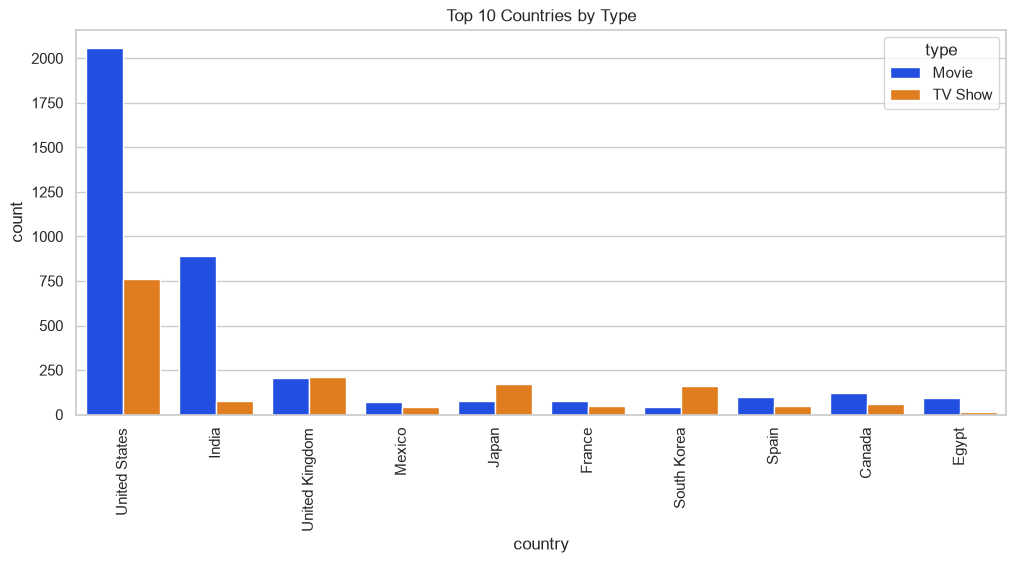

In [21]:
top_country = df["country"].value_counts().head(10).index

plt.figure(figsize=(12,5))
sns.countplot(
    data=df[df["country"].isin(top_country)],
    x="country",
    hue="type"
)
plt.title("Top 10 Countries by Type")
plt.xticks(rotation=90)
plt.show()

**Task 8**  Correlation Analysis


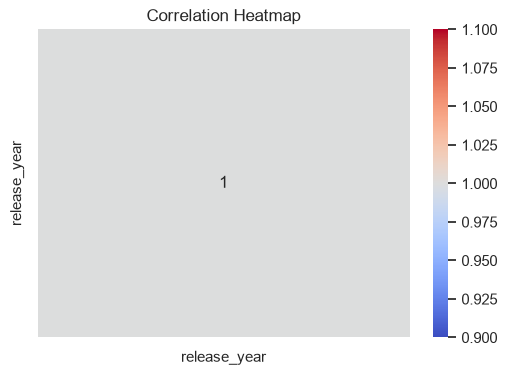

In [22]:
numeric_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [23]:
corr = numeric_df.corr()
print(corr)

              release_year
release_year           1.0


**Task 9** Feature Engineering

In [24]:
df["content_age"] = 2026 - df["release_year"]
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",6
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",5
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,5
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",5
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,5


**Task 10** Business Insights

**Netflix Titles dataset** and the analyses you performed (EDA, univariate, bivariate, missing values, outliers, and feature engineering), here are **10 actionable insights** you can include in your assignment:

1. **Movies dominate the Netflix catalog**, indicating that Netflix offers significantly more movies than TV shows.

2. **The number of titles released has increased over the years**, showing that Netflix has continuously expanded its content library.

3. **The United States contributes the highest number of titles**, making it the largest content-producing country in the dataset.

4. **TV Shows generally have more recent release years than Movies**, suggesting Netflix has invested more in TV series in recent years.

5. **Most titles belong to a few popular ratings** (such as TV-MA and TV-14), indicating that Netflix mainly targets mature and teenage audiences.

6. **Some columns contain missing values** (such as `director`, `cast`, and `country`), so handling missing data is important before building machine learning models.

7. **No meaningful correlation analysis can be performed** because the dataset contains only one numerical feature (`release_year`). Additional numerical features would be required for correlation analysis.

8. **The newly created `content_age` feature** helps identify how old each title is, making it easier to analyze content freshness and trends.

9. **The dataset contains a mix of movies and TV shows across multiple countries, genres, and ratings**, making it suitable for recommendation systems and content trend analysis.

**Task 11** Conclusion

The project successfully explored the Netflix dataset using data cleaning, visualization, feature engineering, and statistical analysis techniques. The results provide a clear understanding of the dataset's characteristics and demonstrate how Exploratory Data Analysis (EDA) can be used to uncover patterns, improve data quality, and prepare data for future machine learning or business intelligence applications.